In [1]:
import __init__ as ini
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100


## CCLE miRNA Expression — `13_CCLE_miRNA_20181103.gct`

734 miRNAs × 954 cell lines in GCT v1.2 format — a specialised genomics file that fails with plain `read_csv`. Must use `pd.read_csv(file, sep='\t', skiprows=2)`, then transpose so cell lines become rows. miRNAs are small RNAs that silence other genes — a regulatory layer distinct from (and sometimes overriding) RNA expression. Cell line column names are in `NAME_TISSUE` (CCLE_ID) format.

### Load GCT file correctly
The GCT v1.2 format has 2 header rows that must be skipped. After loading, we transpose so rows=cell lines.

In [2]:
raw = pd.read_csv(ini.df13, sep="\t", skiprows=2, index_col=0)
# Drop the Description column (miRNA annotation, not expression)
if "Description" in raw.columns:
    raw = raw.drop(columns=["Description"])
# Transpose: rows=cell lines, cols=miRNAs
df = raw.T.copy()
df.index.name = "cell_line"
print(f"Shape after transpose: {df.shape}  (rows=cell lines, cols=miRNAs)")
print(f"First 5 cell lines : {df.index[:5].tolist()}")
print(f"First 5 miRNAs     : {df.columns[:5].tolist()}")


Shape after transpose: (954, 734)  (rows=cell lines, cols=miRNAs)
First 5 cell lines : ['DMS53_LUNG', 'SW1116_LARGE_INTESTINE', 'NCIH1694_LUNG', 'P3HR1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE', 'HUT78_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE']
First 5 miRNAs     : ['nmiR00001.1', 'nmiR00002.1', 'nmiR00003.1', 'nmiR00004.1', 'nmiR00005.1']


### miRNA expression distribution
miRNA values are raw counts (RPM-like). A log transform helps visualise the spread.

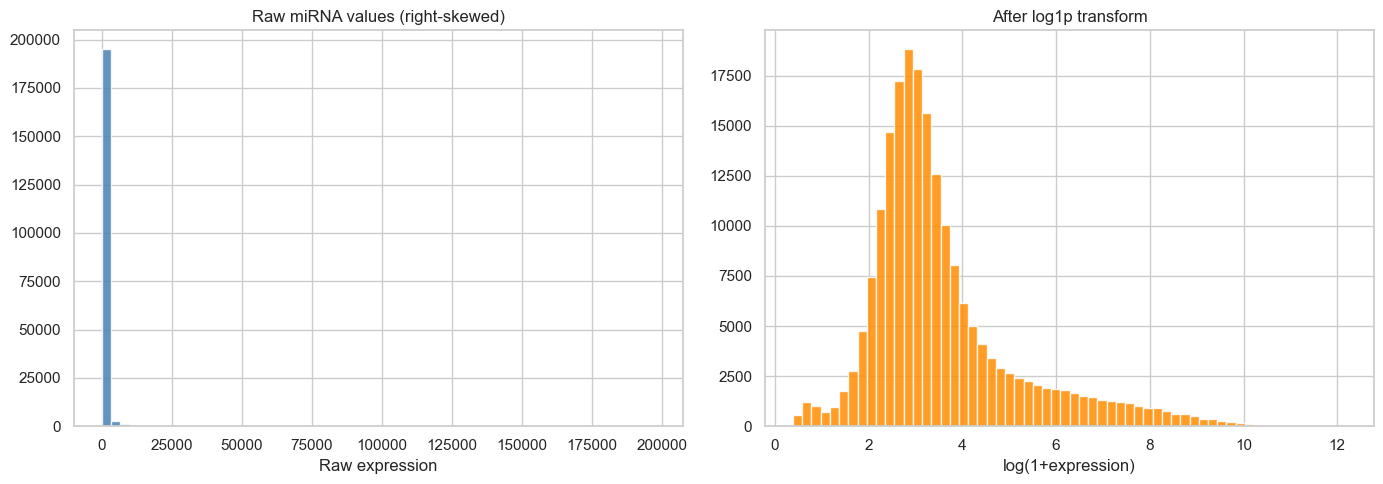

In [3]:
sample_vals = df.values.flatten()
sample_vals = sample_vals[~np.isnan(sample_vals)]
np.random.seed(42)
if len(sample_vals) > 200_000:
    sample_vals = np.random.choice(sample_vals, 200_000, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(sample_vals, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Raw expression"); axes[0].set_title("Raw miRNA values (right-skewed)")

axes[1].hist(np.log1p(sample_vals), bins=60, color="darkorange", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("log(1+expression)"); axes[1].set_title("After log1p transform")

plt.tight_layout(); plt.show()


### Top 20 most expressed and most variable miRNAs
High-expression miRNAs are abundant across most lines; high-variance miRNAs differentiate cell lines.

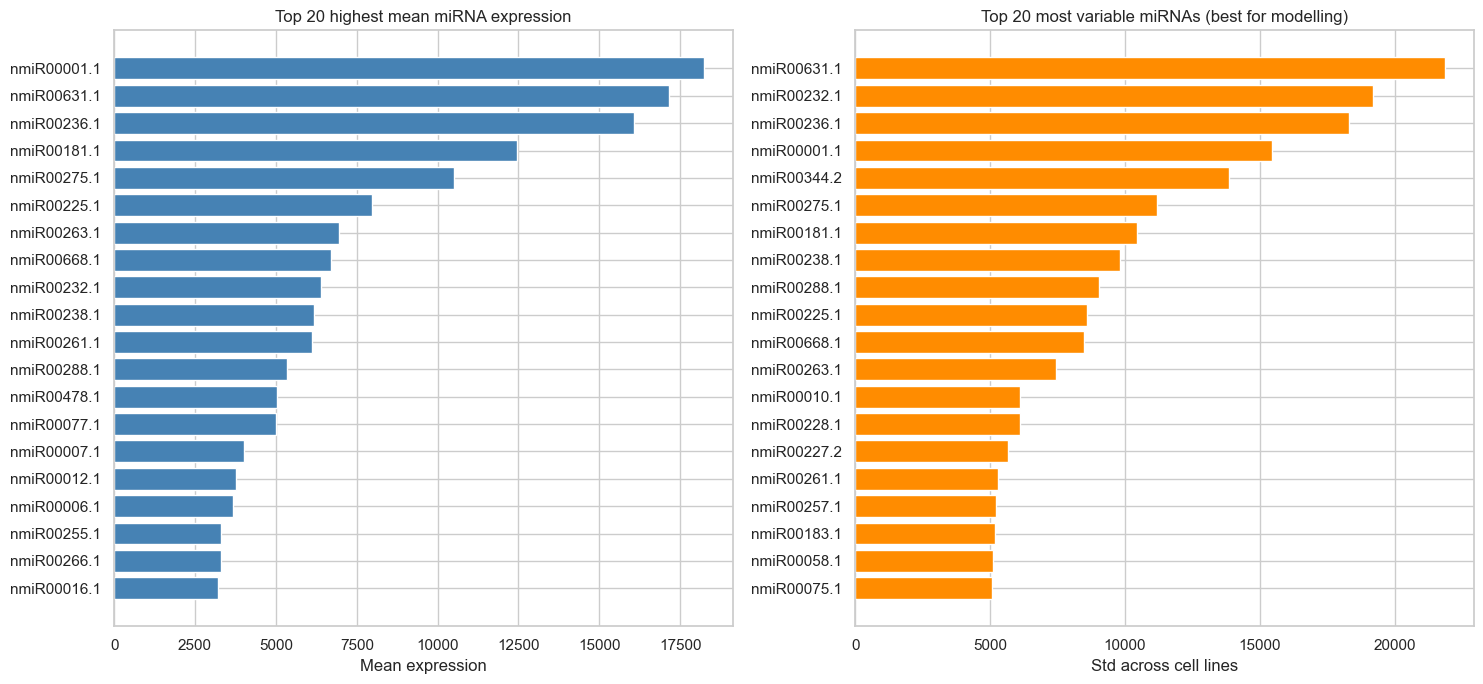

In [4]:
mir_mean = df.mean().sort_values(ascending=False)
mir_std  = df.std().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].barh(mir_mean.head(20).index[::-1], mir_mean.head(20).values[::-1], color="steelblue")
axes[0].set_title("Top 20 highest mean miRNA expression")
axes[0].set_xlabel("Mean expression")

axes[1].barh(mir_std.head(20).index[::-1], mir_std.head(20).values[::-1], color="darkorange")
axes[1].set_title("Top 20 most variable miRNAs (best for modelling)")
axes[1].set_xlabel("Std across cell lines")

plt.tight_layout(); plt.show()


### miRNA class breakdown
Most miRNAs are human (hsa-); a small number are viral (kshv = Kaposi's sarcoma virus, mcv = Merkel cell virus).

In [5]:
classes = {
    "hsa-miR (human)": df.columns.str.startswith("hsa-miR"),
    "hsa-let (human)": df.columns.str.startswith("hsa-let"),
    "kshv-miR (Kaposi virus)": df.columns.str.startswith("kshv"),
    "mcv-miR (Merkel virus)": df.columns.str.startswith("mcv")
}

# 1. Calculate counts
counts = {k: v.sum() for k, v in classes.items()}
print("Raw counts:", counts)

# 2. Filter out categories that have a count of 0 
# (This prevents empty labels from crowding your chart)
filtered_counts = {k: v for k, v in counts.items() if v > 0}

# 3. Check if there is actually data to plot before drawing the figure
if sum(filtered_counts.values()) == 0:
    print("Error: Total sum of counts is 0. No pie chart will be drawn.")
else:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.pie(
        filtered_counts.values(), 
        labels=filtered_counts.keys(), 
        autopct="%1.1f%%", 
        startangle=90
    )
    ax.set_title("miRNA class distribution")
    plt.tight_layout()
    plt.show()

Raw counts: {'hsa-miR (human)': np.int64(0), 'hsa-let (human)': np.int64(0), 'kshv-miR (Kaposi virus)': np.int64(0), 'mcv-miR (Merkel virus)': np.int64(0)}
Error: Total sum of counts is 0. No pie chart will be drawn.


### PCA of cell lines by miRNA profile
Each dot = one cell line. Clustering in this space reflects shared miRNA regulation patterns.

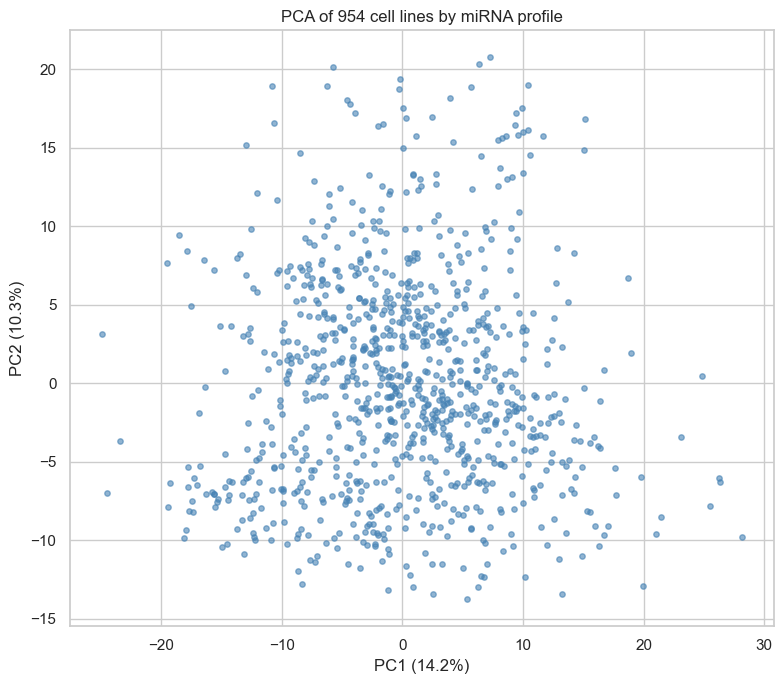

In [6]:
X_mir = np.log1p(df.values)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_mir)
var_exp = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(coords[:, 0], coords[:, 1], alpha=0.6, s=15, color="steelblue")
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)")
ax.set_title(f"PCA of {len(df)} cell lines by miRNA profile")
plt.tight_layout(); plt.show()


### Key findings

In [7]:
print("=== CCLE miRNA ===")
print(f"Cell lines  : {df.shape[0]}")
print(f"miRNAs      : {df.shape[1]}")
print(f"hsa-miR     : {df.columns.str.startswith('hsa-miR').sum()}")
print(f"kshv/mcv    : {(df.columns.str.startswith('kshv') | df.columns.str.startswith('mcv')).sum()}")
print(f"PCA PC1+PC2 : {sum(pca.explained_variance_ratio_)*100:.1f}% variance")
print(f"Top miRNA   : {mir_mean.idxmax()} (mean={mir_mean.max():.1f})")


=== CCLE miRNA ===
Cell lines  : 954
miRNAs      : 734
hsa-miR     : 0
kshv/mcv    : 0
PCA PC1+PC2 : 24.5% variance
Top miRNA   : nmiR00001.1 (mean=18221.5)


## Deeper dive: miRNA PCA coloured by lineage + viral miRNA carriers

Does miRNA regulation cluster by tissue? We colour the PCA by lineage. We also locate
the cell lines carrying viral miRNAs (kshv = Kaposi sarcoma herpesvirus, mcv = Merkel
cell polyomavirus) - their presence is a biological fingerprint of viral-driven cancers.

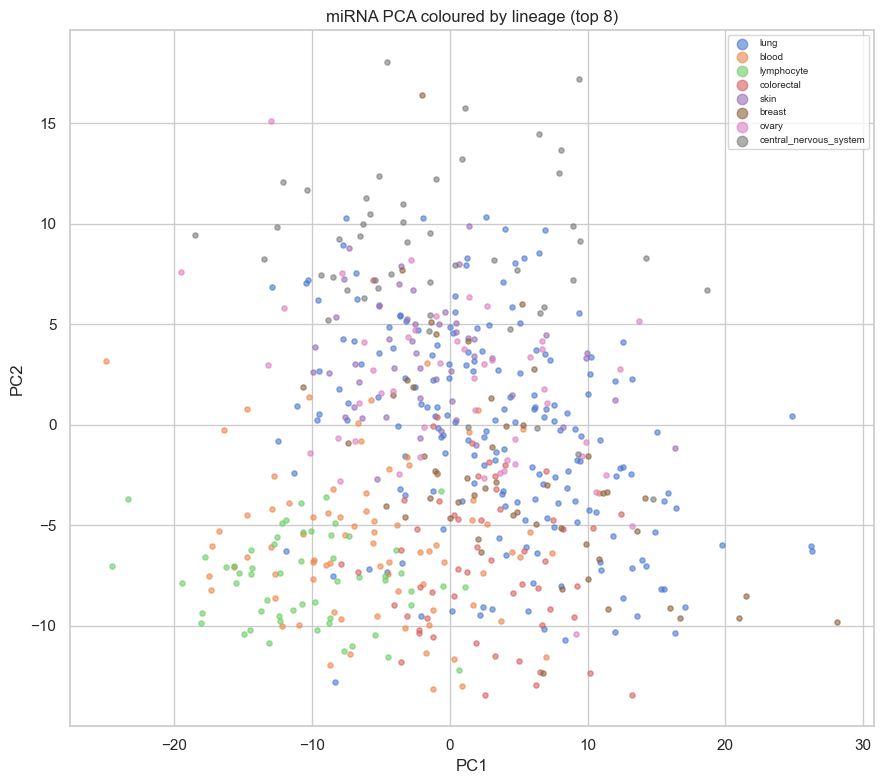

In [8]:
import __init__ as ini
from sklearn.decomposition import PCA
lin = pd.read_csv(ini.df9, usecols=["CCLE_Name","lineage"]).dropna(subset=["CCLE_Name"]).drop_duplicates("CCLE_Name").set_index("CCLE_Name")["lineage"]
lins = np.array(df.index.map(lin))
coords = PCA(n_components=2, random_state=42).fit_transform(np.log1p(df.values))
topL = pd.Series(lins).value_counts().head(8).index
fig, ax = plt.subplots(figsize=(9,8))
for l in topL:
    m = lins == l
    ax.scatter(coords[m,0], coords[m,1], s=14, alpha=0.6, label=l)
ax.legend(fontsize=7, markerscale=2); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("miRNA PCA coloured by lineage (top 8)")
plt.tight_layout(); plt.show()
viral = [c for c in df.columns if c.startswith("kshv") or c.startswith("mcv")]
if viral:
    carriers = (df[viral] > df[viral].mean()).any(axis=1)
    print(f"viral miRNA columns: {len(viral)}; lines with above-mean viral miRNA: {int(carriers.sum())}")
    print("examples:", list(df.index[carriers][:8]))

## In Plain English — What This Dataset Means & Where It Goes Next

### 1. What this data actually is (layman terms)
Cells have tiny molecules called **miRNAs that act like dimmer switches** — they quietly turn *down* the activity of other genes (i.e., short regulatory RNAs that fine-tune how loud the gene "volume dials" play). This file measures **734 of these dimmer switches across 954 cell lines**. It's a **separate regulatory layer**: two cells with identical gene instructions can behave differently because their dimmer switches are set differently.

### 2. What we found, and the next steps (preprocessing + missing EDA)
What the notebook showed:
- The raw file is **sideways** (cell lines are columns) — it's a **GCT file**, so it **must be transposed** to get 954 cell lines as rows × 734 miRNAs as columns.
- Values are **raw counts and right-skewed** (a few miRNAs dominate).
- The miRNA names are **anonymized** (`nmiR00001.1` style) rather than standard biological names — so we can't look up what each one does individually.
- It joins to the metabolomics file via `CCLE_ID`, reaching ~95.8% of those lines.

Next steps (preprocessing):
- **Transpose first** (this is the easy mistake to miss).
- **Join via `CCLE_ID` → metabolomics (df12) → DepMap.**
- **log1p-transform** the right-skewed counts.

Still missing in EDA:
- **Try to map the anonymized `nmiR` IDs back to real miRNA names** (if a key exists); otherwise we treat them as opaque, unnamed features — usable for math, but not for biological storytelling.

### 3. Which ML approach fits this dataset
**Unsupervised feature source — a supplementary regulatory layer.** It adds a genuinely different signal (regulation, not just expression), but because the miRNAs are unnamed it contributes more to *prediction* than to *human-readable justification*.

> **Big-picture note:** miRNA is one of the **enrichment layers** on the DepMap spine; valuable for accuracy, weaker for the explainable "why this line" story until the IDs are decoded.